In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "zahn.csv",
    sep="\t",
    header=None,
    names=["X", "Y", "Clase"]
)

df.head()

,X,Y,Clase
0,26.75,22.15,0
1,29.80,22.15,0
2,31.55,21.10,0
3,27.70,20.85,0
4,29.90,19.95,0


In [4]:
df.info()

df["Clase"].value_counts().sort_index()

<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       399 non-null    float64
 1   Y       399 non-null    float64
 2   Clase   399 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


Clase
0     50
1     92
2     83
3    158
4     16
Name: count, dtype: int64

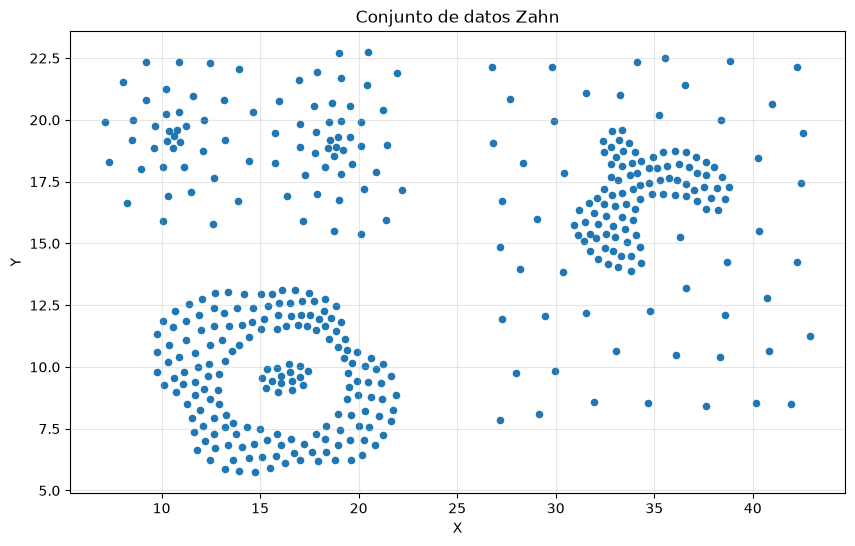

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["X"],
    df["Y"],
    s=20
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Conjunto de datos Zahn")
plt.grid(alpha=0.3)

plt.show()

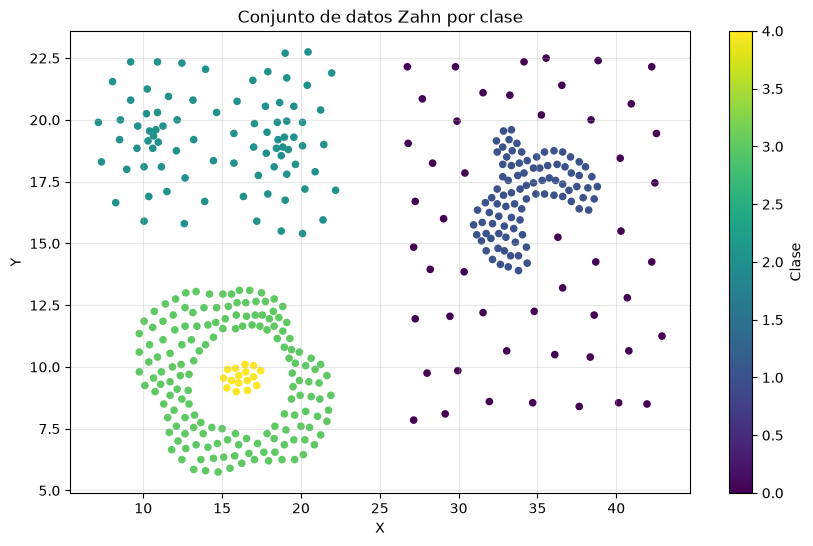

In [6]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["X"],
    df["Y"],
    c=df["Clase"],
    s=20
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Conjunto de datos Zahn por clase")
plt.colorbar(scatter, label="Clase")
plt.grid(alpha=0.3)

plt.show()

# 1: Encontrar el diametro del espacio, DIAM(Z):
Procedimiento:
1. Se calcula la distancia Euclidiana (diametro) entre cada vector.
2. Se campara cada una para encontrar la distancia mas larga entre 2 vectores
3. Se reporta el hayazgo.

In [7]:
import numpy as np
from scipy.spatial.distance import cdist

# Tomamos únicamente las columnas X y Y
Z = df[["X", "Y"]].to_numpy()

# Matriz de distancias euclidianas entre todos los vectores
distancias = cdist(Z, Z, metric="euclidean")

print(distancias.shape)

(399, 399)


In [8]:
distancias[:5, :5]

array([[0.        , 3.05      , 4.91350181, 1.61012422, 3.84219989],
       [3.05      , 0.        , 2.04083316, 2.46981781, 2.20227155],
       [4.91350181, 2.04083316, 0.        , 3.85810834, 2.01121854],
       [1.61012422, 2.46981781, 3.85810834, 0.        , 2.37697286],
       [3.84219989, 2.20227155, 2.01121854, 2.37697286, 0.        ]])

In [9]:
# Busca el elemento mas grande de toda la matriz de distancias

Diam_Z = np.max(distancias)

print(f"Diámetro de Z: {Diam_Z:.4f}")

Diámetro de Z: 36.7816


In [10]:
# Muestra cuales son los vectores que generan el diámetro de Z
i, j = np.unravel_index(
    np.argmax(distancias),
    distancias.shape
)

print("Índice del primer vector:", i)
print("Índice del segundo vector:", j)

print("Vector 1:", Z[i])
print("Vector 2:", Z[j])

Índice del primer vector: 36
Índice del segundo vector: 152
Vector 1: [42.9  11.25]
Vector 2: [ 7.15 19.9 ]


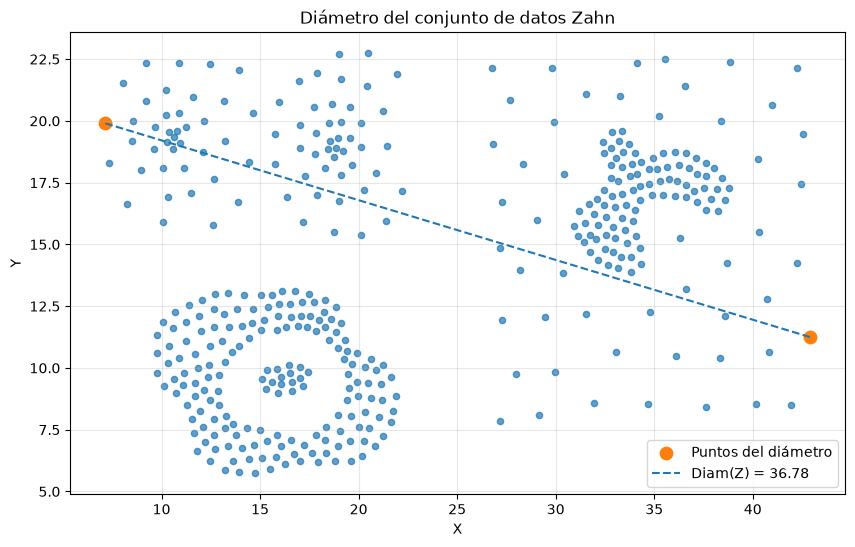

In [11]:
# Graficamos el diametro de Z

plt.figure(figsize=(10, 6))

# Todos los datos
plt.scatter(
    df["X"],
    df["Y"],
    s=20,
    alpha=0.7
)

# Puntos que generan el diámetro
plt.scatter(
    [Z[i, 0], Z[j, 0]],
    [Z[i, 1], Z[j, 1]],
    s=80,
    label="Puntos del diámetro"
)

# Línea correspondiente al diámetro
plt.plot(
    [Z[i, 0], Z[j, 0]],
    [Z[i, 1], Z[j, 1]],
    linestyle="--",
    label=f"Diam(Z) = {Diam_Z:.2f}"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Diámetro del conjunto de datos Zahn")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 2: Generación del conjunto de radios R

Dados $Diam(Z) = 36$ y $N = 10$ se contruye el conjunto de radios.

In [12]:
Diam_Z = 36
N = 10

R = np.array([
    Diam_Z / i
    for i in range(N, 0, -1)
])

R

array([ 3.6       ,  4.        ,  4.5       ,  5.14285714,  6.        ,
        7.2       ,  9.        , 12.        , 18.        , 36.        ])

In [13]:
print("Valores de R:")
for i, r in enumerate(R):
    print(f"R{i} = {r:.4f}")

Valores de R:
R0 = 3.6000
R1 = 4.0000
R2 = 4.5000
R3 = 5.1429
R4 = 6.0000
R5 = 7.2000
R6 = 9.0000
R7 = 12.0000
R8 = 18.0000
R9 = 36.0000


# 3: Generar el histograma de densidad en X.

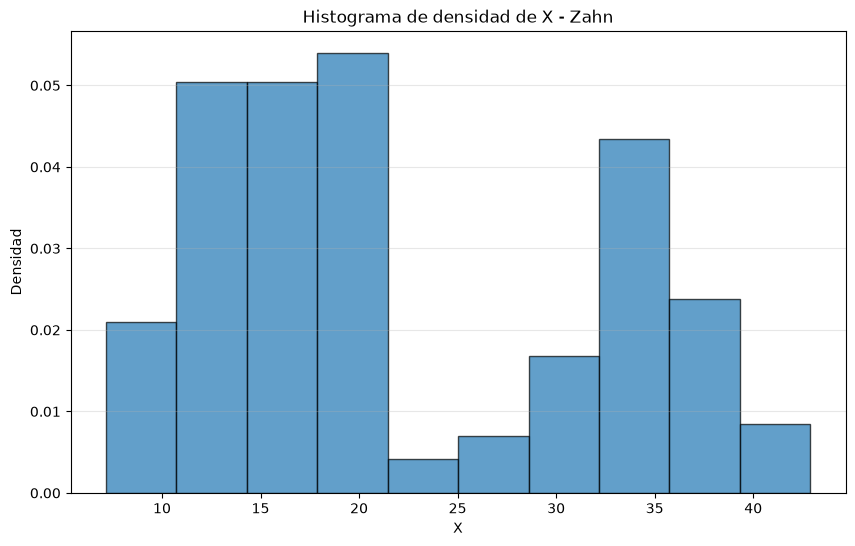

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["X"],
    bins="auto",
    density=True,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("X")
plt.ylabel("Densidad")
plt.title("Histograma de densidad de X - Zahn")
plt.grid(axis="y", alpha=0.3)

plt.show()

# 4: Generar el histograma de densidad en Y.

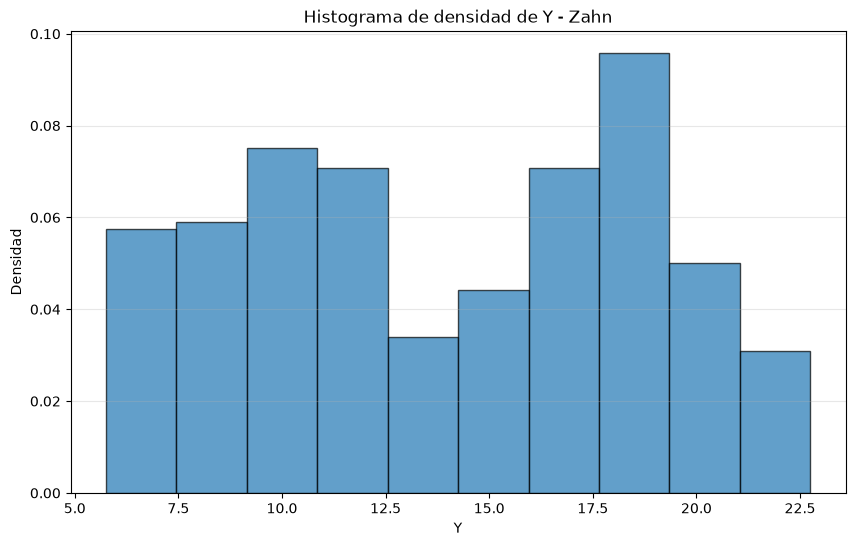

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Y"],
    bins="auto",
    density=True,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Y")
plt.ylabel("Densidad")
plt.title("Histograma de densidad de Y - Zahn")
plt.grid(axis="y", alpha=0.3)

plt.show()

# 5. Encontrar, para cada valor R en *R*, las DB($pi$,*R*) - Anomalias.

In [16]:
P = [0.01, 0.02, 0.05, 0.10]

n = len(Z)

resultados_db = {}

for r in R:
    # Número de vectores a una distancia mayor que r
    puntos_lejanos = np.sum(distancias > r, axis=1)

    for p in P:
        # Condición DB(p,r)
        anomalías = puntos_lejanos >= p * n

        resultados_db[(p, r)] = anomalías

In [17]:
resultados_resumen = []

for r in R:
    for p in P:
        anomalías = resultados_db[(p, r)]

        resultados_resumen.append({
            "r": r,
            "p": p,
            "num_anomalias": np.sum(anomalías)
        })

resumen_db = pd.DataFrame(resultados_resumen)

resumen_db

,r,p,num_anomalias
0,3.600000,0.01,399
1,3.600000,0.02,399
2,3.600000,0.05,399
3,3.600000,0.10,399
4,4.000000,0.01,399
5,4.000000,0.02,399
6,4.000000,0.05,399
7,4.000000,0.10,399
8,4.500000,0.01,399
9,4.500000,0.02,399


In [18]:
# Analizamos los resultados para p=0.10 y r=18
p = 0.10
r = 18

anomalías = resultados_db[(p, r)]

df[anomalías]

,X,Y,Clase
0,26.75,22.15,0
1,29.80,22.15,0
2,31.55,21.10,0
3,27.70,20.85,0
4,29.90,19.95,0
...,...,...,...
394,15.85,9.95,4
395,15.35,9.90,4
396,15.60,9.45,4
397,15.30,9.15,4


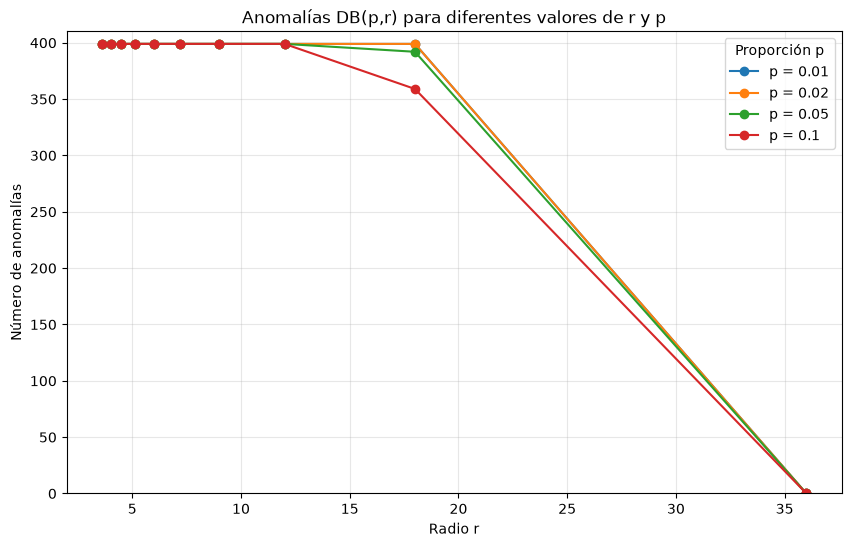

In [19]:
# Graficacion x=r, y=numAnomalias, color=p
plt.figure(figsize=(10, 6))

for p in P:
    datos_p = resumen_db[resumen_db["p"] == p]

    plt.plot(
        datos_p["r"],
        datos_p["num_anomalias"],
        marker="o",
        label=f"p = {p}"
    )

plt.xlabel("Radio r")
plt.ylabel("Número de anomalías")
plt.title("Anomalías DB(p,r) para diferentes valores de r y p")
plt.ylim(0, 410)
plt.grid(alpha=0.3)
plt.legend(title="Proporción p")

plt.show()

# 6. Visualizar los resultados del analisis de anomalias 


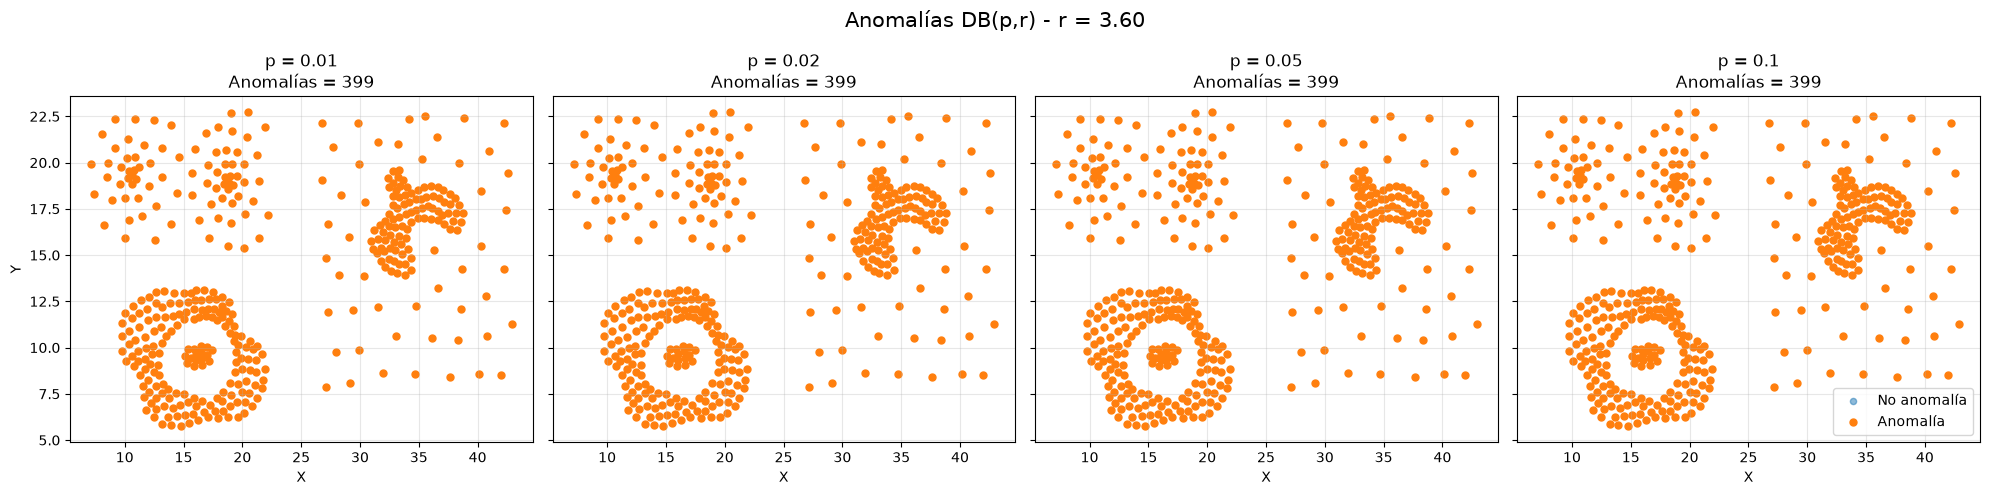

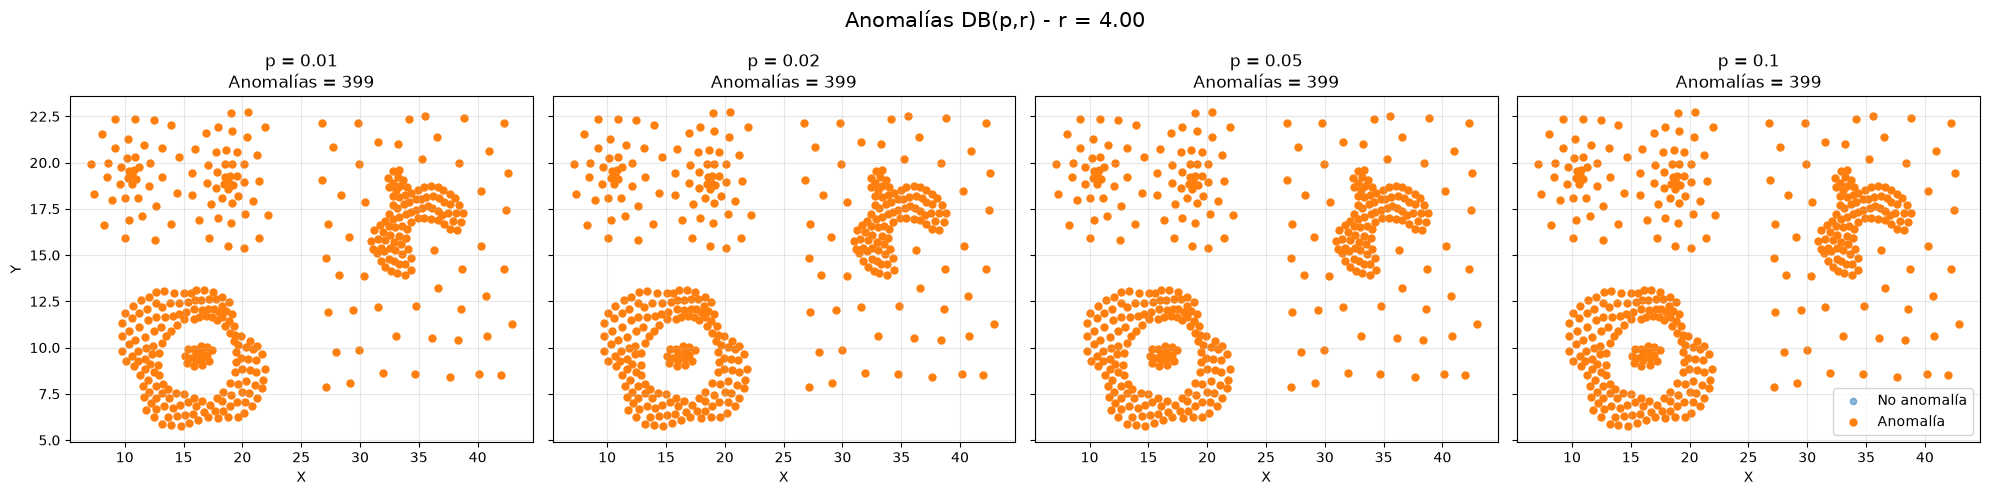

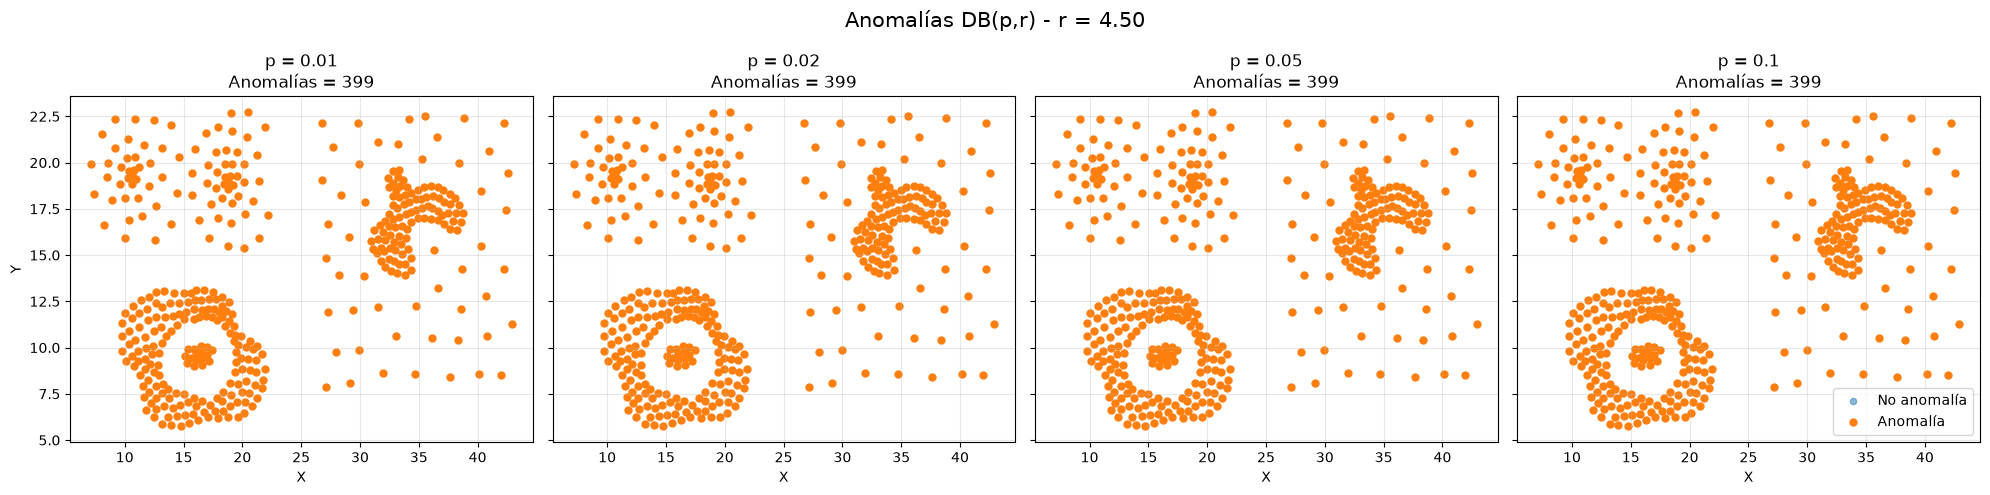

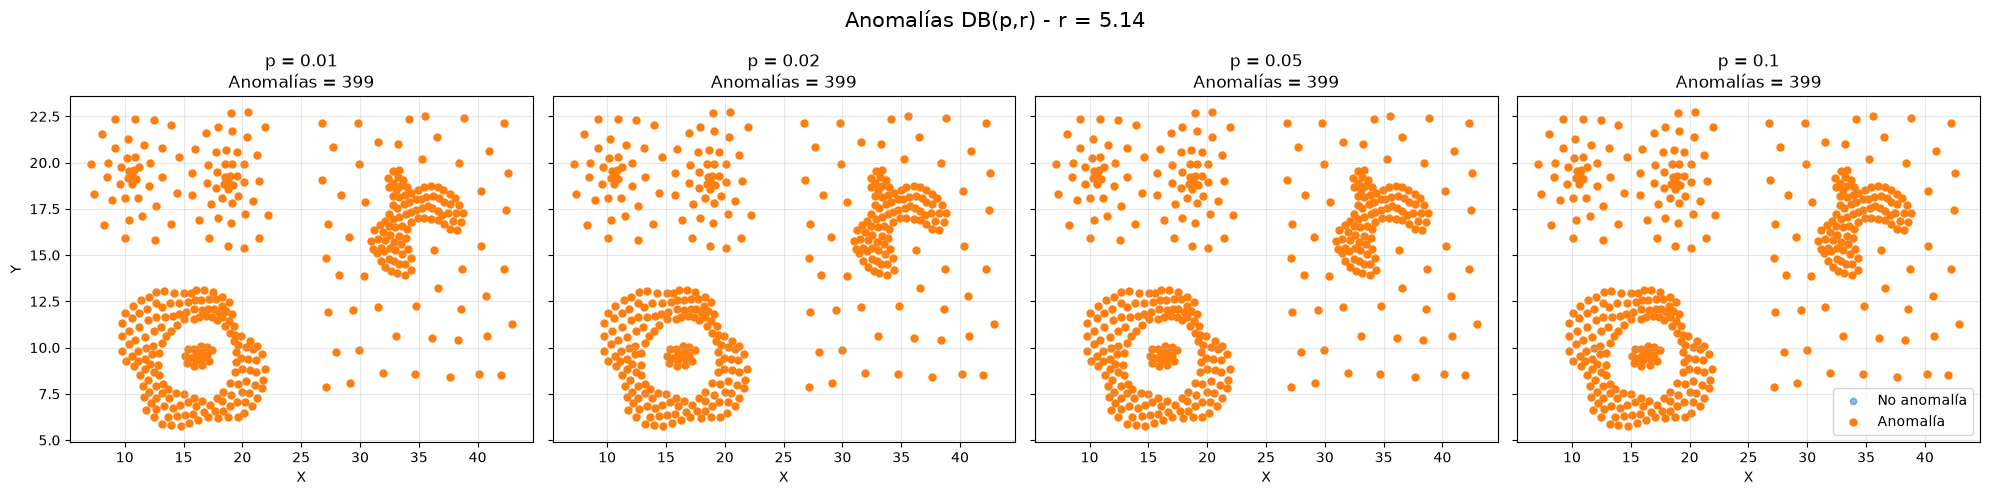

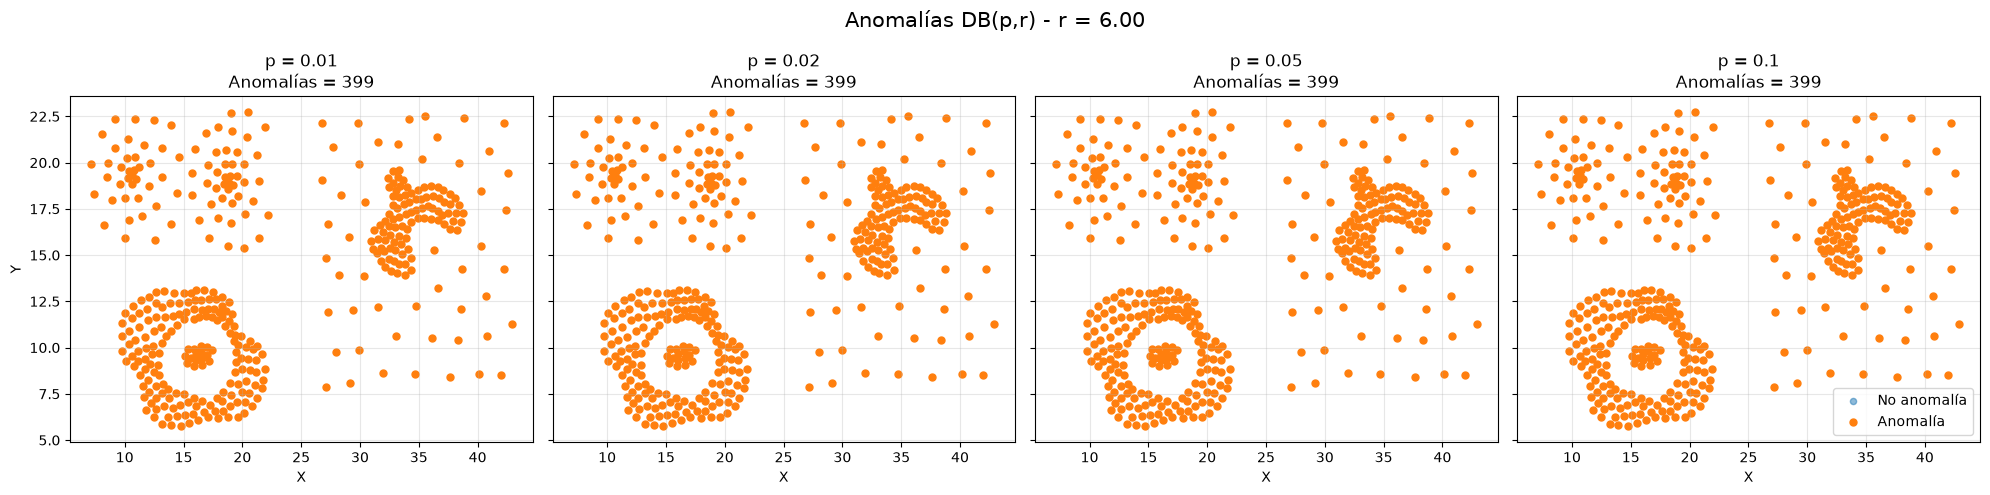

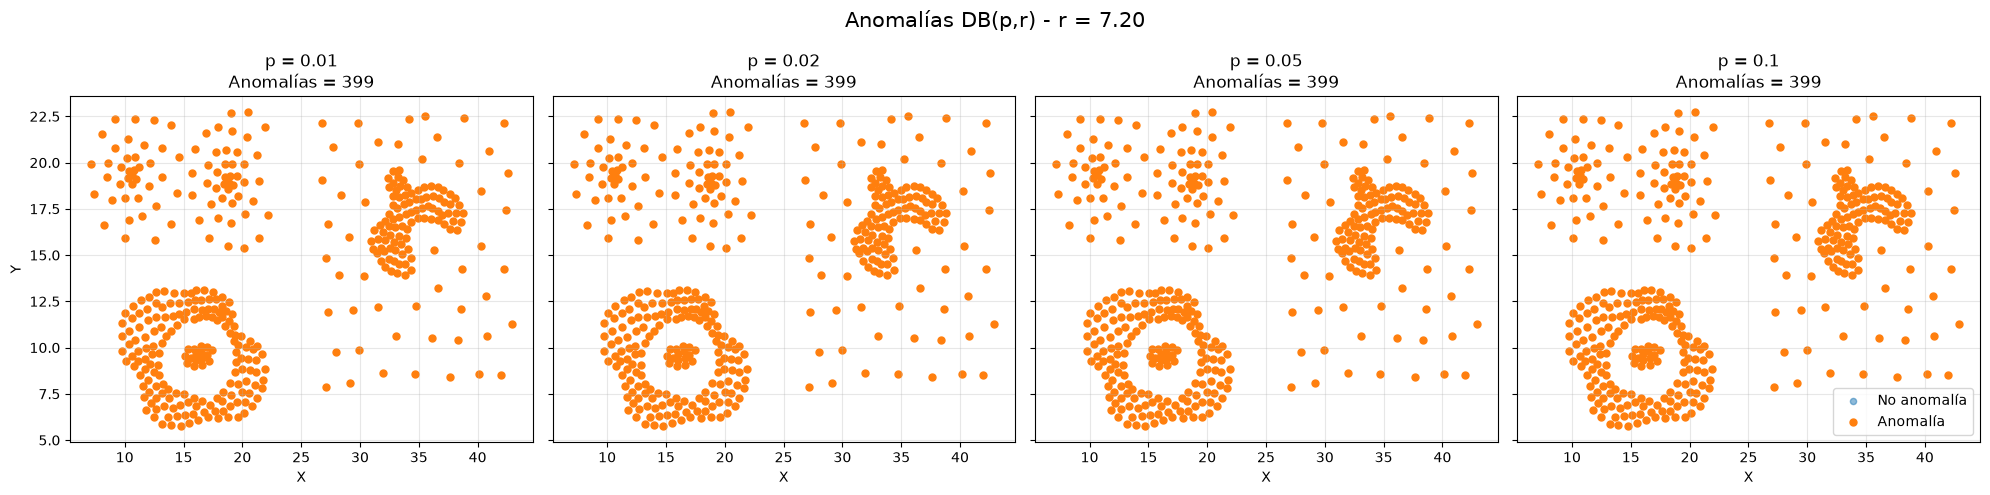

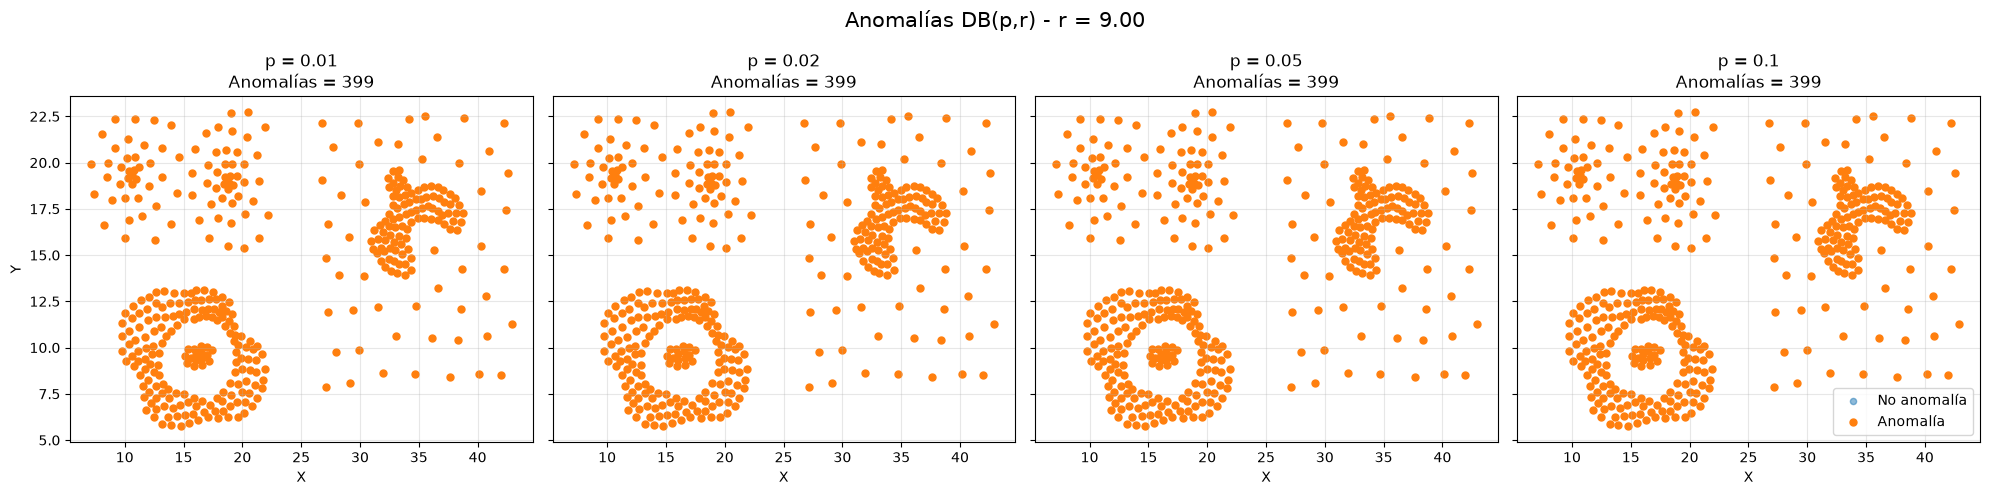

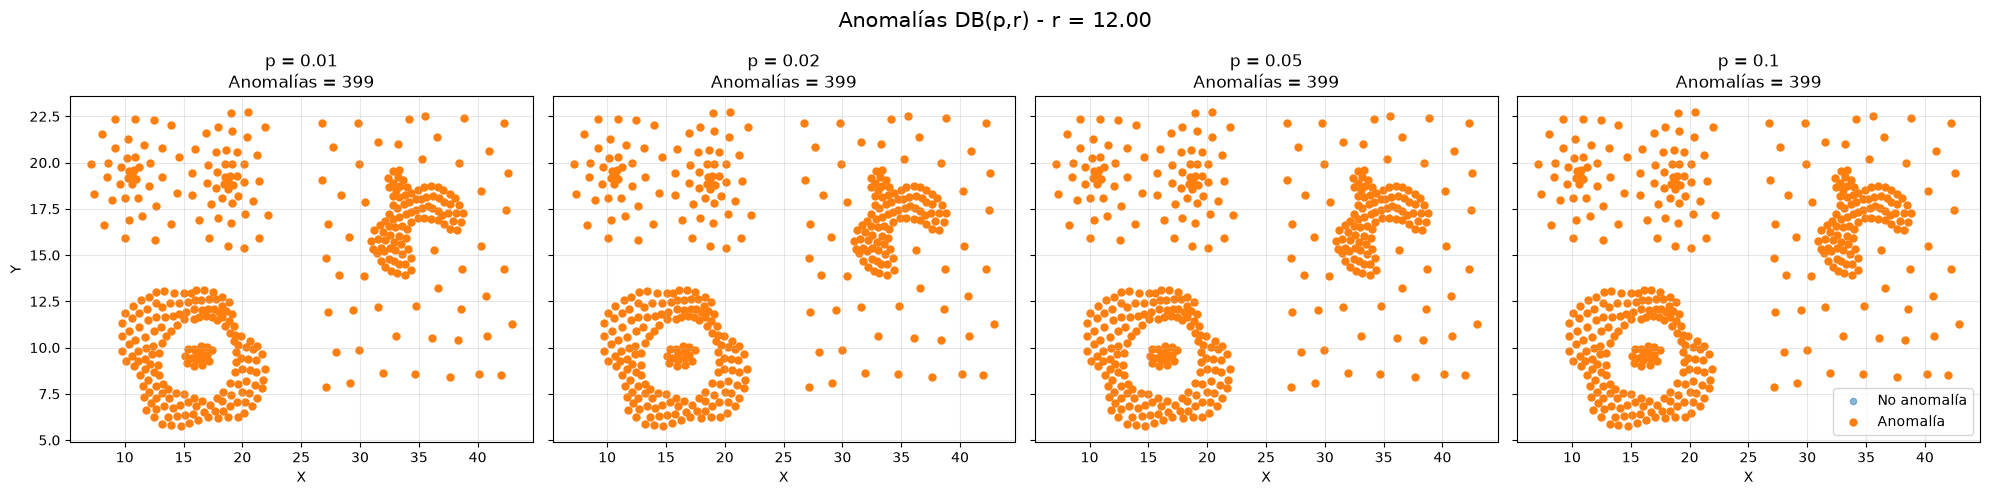

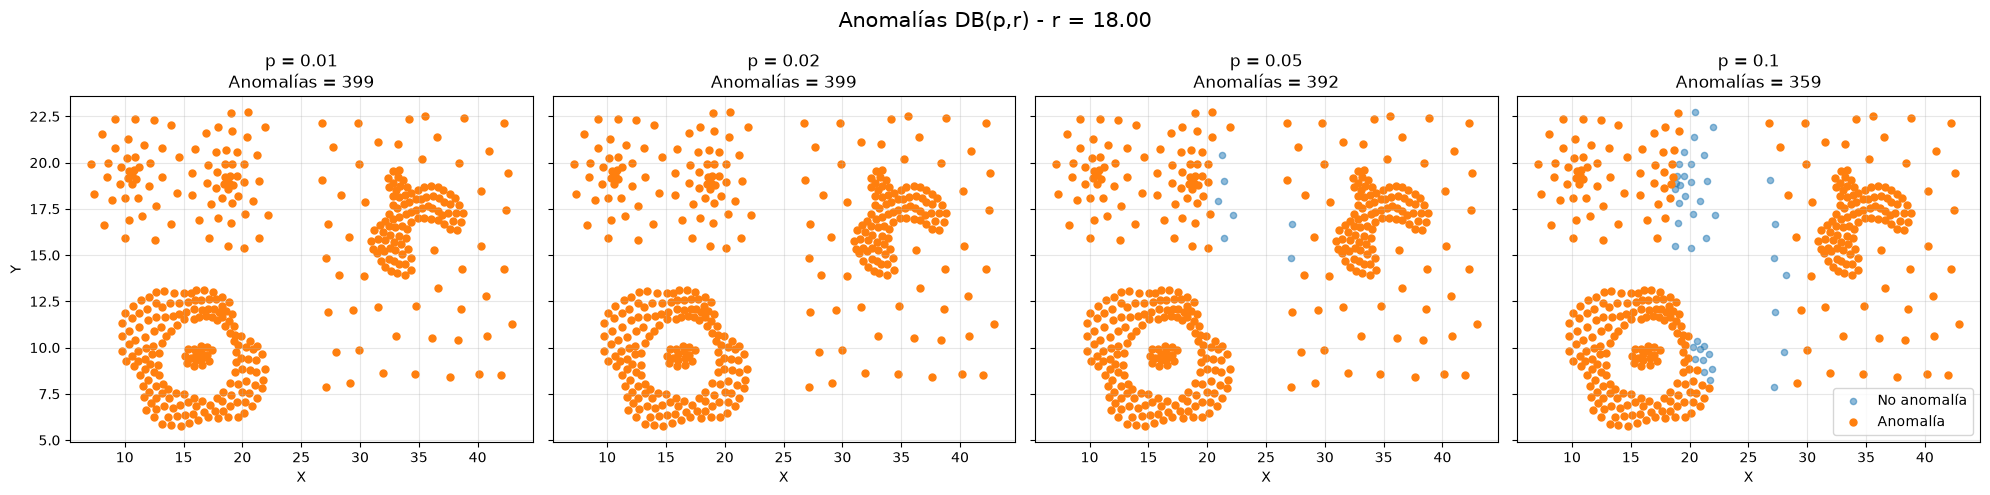

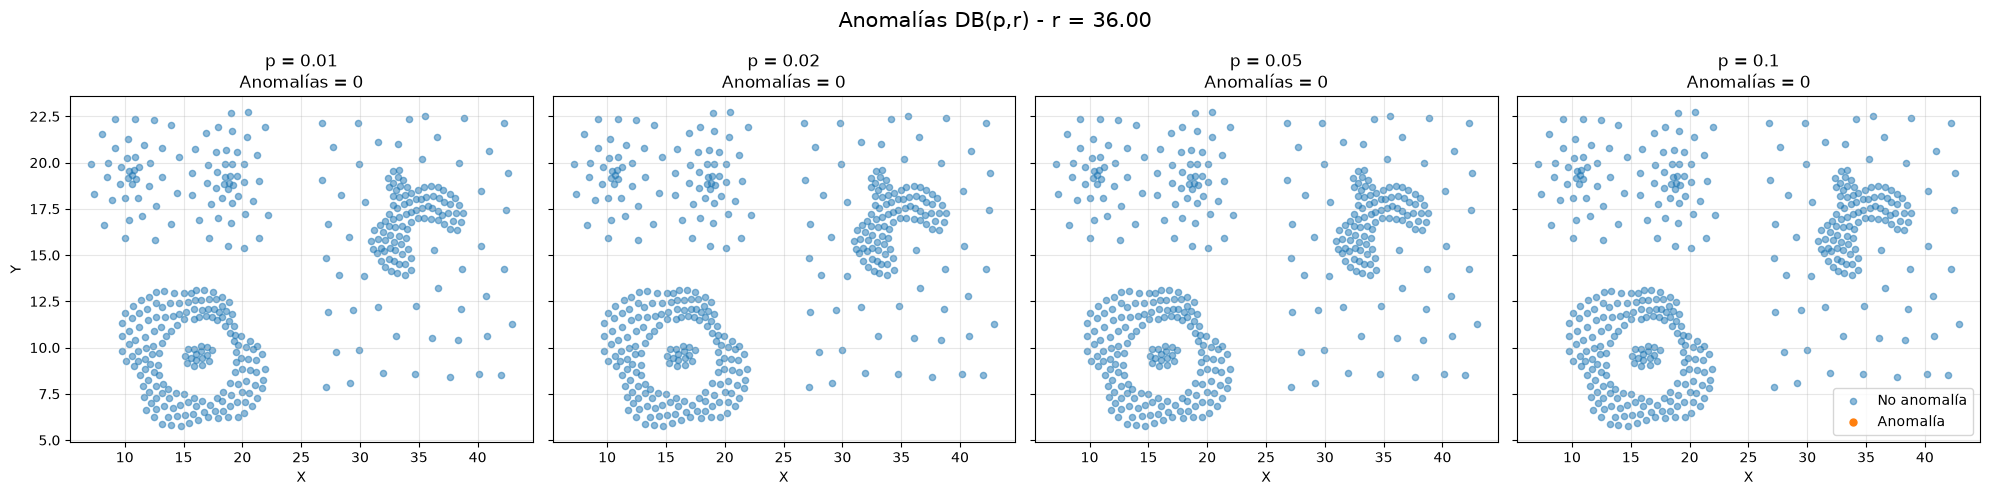

In [20]:
for r in R:

    fig, axes = plt.subplots(
        1, 4,
        figsize=(20, 5),
        sharex=True,
        sharey=True
    )

    for ax, p in zip(axes, P):

        anomalias = resultados_db[(p, r)]

        # Puntos que NO cumplen DB(p,r)
        ax.scatter(
            Z[~anomalias, 0],
            Z[~anomalias, 1],
            s=20,
            alpha=0.5,
            label="No anomalía"
        )

        # Puntos que SÍ cumplen DB(p,r)
        ax.scatter(
            Z[anomalias, 0],
            Z[anomalias, 1],
            s=25,
            label="Anomalía"
        )

        ax.set_title(
            f"p = {p}\nAnomalías = {np.sum(anomalias)}"
        )

        ax.set_xlabel("X")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Y")
    axes[-1].legend()

    fig.suptitle(
        f"Anomalías DB(p,r) - r = {r:.2f}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

# 7. Distancia esperada de cada vector al resto de los vectores.
E(v) es la distancia esperada (promedio) del vector V al resto


$$
E(v_i)=\frac{1}{N-1}\sum_{\substack{j=1 \\ j\neq i}}^{N} d(v_i,v_j)
$$

In [21]:
N = len(Z)

E = np.sum(distancias, axis=1) / (N - 1)

E

array([13.60784242, 14.43244812, 14.48731964, 13.11422493, 13.31495302,
       12.09123381, 12.19244164, 12.69773429, 11.50019115, 11.88941291,
       11.24534178, 11.55224744, 12.31379551, 11.48411818, 12.2450568 ,
       13.12397606, 14.36697   , 13.09331978, 12.3394982 , 12.80734443,
       13.46564758, 14.56062246, 16.17109783, 14.96770719, 15.59698722,
       16.04316705, 17.59659401, 18.96512257, 20.78448079, 19.50769397,
       17.83626686, 16.3646084 , 18.07740926, 18.25676606, 20.14048151,
       20.03180948, 21.76433799, 21.66352406, 21.12965602, 19.29049523,
       21.63840502, 20.57815602, 22.29152913, 19.60693023, 18.18238311,
       15.95531472, 15.20637525, 16.43836066, 17.34618886, 17.41143989,
       14.56813736, 14.29650853, 13.91922007, 13.7674948 , 14.00254992,
       14.31839948, 14.52231157, 14.24541019, 13.97764668, 13.75824338,
       14.55854942, 14.32083237, 14.0171138 , 13.61451236, 13.75024733,
       14.12255566, 14.38040268, 14.64645838, 15.07255502, 14.80

In [22]:
df["E"] = E

df.head()

,X,Y,Clase,E
0,26.75,22.15,0,13.607842
1,29.80,22.15,0,14.432448
2,31.55,21.10,0,14.487320
3,27.70,20.85,0,13.114225
4,29.90,19.95,0,13.314953


In [23]:
print(f"Distancia esperada mínima: {E.min():.4f}")
print(f"Distancia esperada máxima: {E.max():.4f}")
print(f"Distancia esperada promedio: {E.mean():.4f}")

indice_max = np.argmax(E)

print("Vector con mayor distancia esperada:")
print(df.iloc[indice_max])

Distancia esperada mínima: 9.9325
Distancia esperada máxima: 22.2915
Distancia esperada promedio: 13.1878
Vector con mayor distancia esperada:
X        42.250000
Y        22.150000
Clase     0.000000
E        22.291529
Name: 42, dtype: float64


# 8. Densidad de cada vector: Número de vecinos en una hiperesfera de radio.
$$R = (Diam(z)/2,Diam(z)/3,Diam(z)/3,Diam(z)/10)$$

$D(v,r)$ es la densidad del vector $v$ para una hiperesfera de radio $r$

In [24]:
Diam_real = np.max(distancias)

print(f"Diam(Z) = {Diam_real:.4f}")

radios_densidad = [
    ("Diam/2", Diam_real / 2),
    ("Diam/3_1", Diam_real / 3),
    ("Diam/3_2", Diam_real / 3),
    ("Diam/10", Diam_real / 10)
]

for nombre, r in radios_densidad:

    D = np.sum(
        (distancias <= r) & (distancias > 0),
        axis=1
    )

    df[f"D_{nombre}"] = D

df[
    ["X", "Y", "D_Diam/2", "D_Diam/3_1", "D_Diam/3_2", "D_Diam/10"]
].head()

Diam(Z) = 36.7816


,X,Y,D_Diam/2,D_Diam/3_1,D_Diam/3_2,D_Diam/10
0,26.75,22.15,329,153,153,3
1,29.80,22.15,271,153,153,5
2,31.55,21.10,250,143,143,19
3,27.70,20.85,331,165,165,5
4,29.90,19.95,296,162,162,16


# 9. Graficar Zahn, codificando E(v) y D(v) en color o forma del punto.

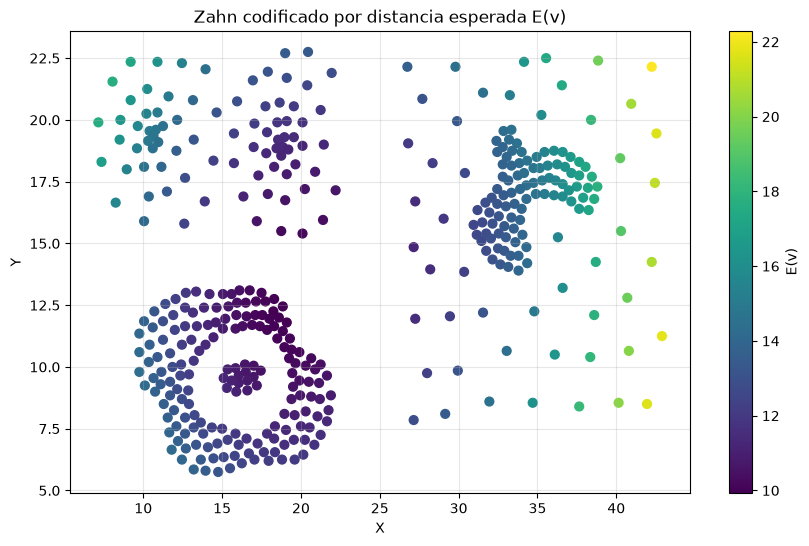

In [25]:
# Grafica de E(v)
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["X"],
    df["Y"],
    c=df["E"],
    cmap="viridis",
    s=40
)

plt.colorbar(scatter, label="E(v)")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Zahn codificado por distancia esperada E(v)")
plt.grid(alpha=0.3)

plt.show()

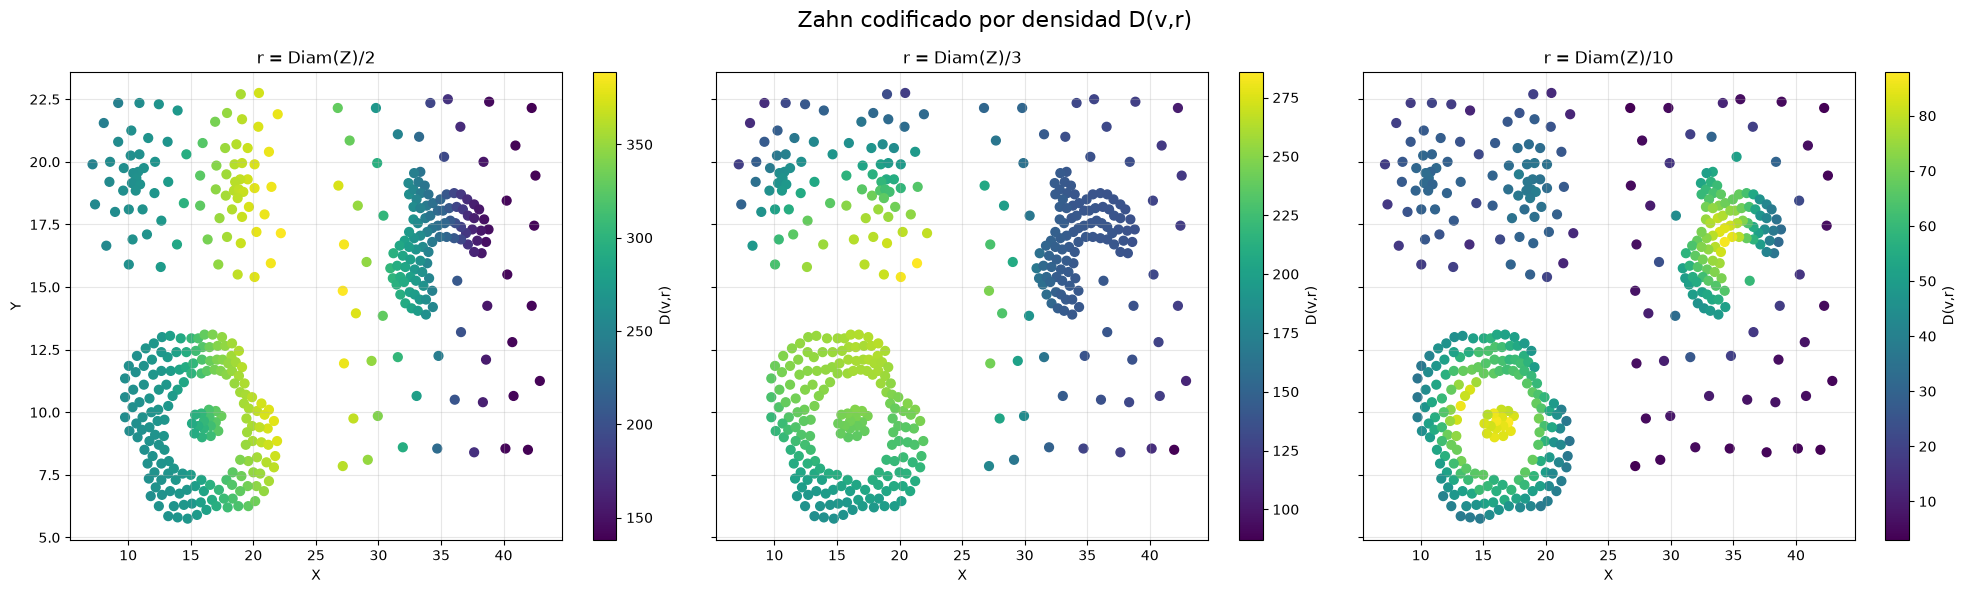

In [26]:
# Grafica D(v,r)
columnas_densidad = [
    ("D_Diam/2", "r = Diam(Z)/2"),
    ("D_Diam/3_1", "r = Diam(Z)/3"),
    ("D_Diam/10", "r = Diam(Z)/10")
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for ax, (columna, titulo) in zip(axes, columnas_densidad):

    scatter = ax.scatter(
        df["X"],
        df["Y"],
        c=df[columna],
        cmap="viridis",
        s=40
    )

    ax.set_title(titulo)
    ax.set_xlabel("X")
    ax.grid(alpha=0.3)

    plt.colorbar(
        scatter,
        ax=ax,
        label="D(v,r)"
    )

axes[0].set_ylabel("Y")

fig.suptitle(
    "Zahn codificado por densidad D(v,r)",
    fontsize=16
)

plt.tight_layout()
plt.show()

# 10. Graficar Zahn, codificando $S(v,r) = E(v)/D(v,r)$

- \(E(v)\): qué tan lejos está el vector, en promedio, de todo el conjunto.
- \(D(v,r)\): cuántos vecinos tiene cerca, dentro del radio \(r\).
- \(S(v,r)\): combina ambas características.

In [27]:
df["S_Diam/2"] = np.where(
    df["D_Diam/2"] > 0,
    df["E"] / df["D_Diam/2"],
    np.nan
)

df["S_Diam/3"] = np.where(
    df["D_Diam/3_1"] > 0,
    df["E"] / df["D_Diam/3_1"],
    np.nan
)

df["S_Diam/10"] = np.where(
    df["D_Diam/10"] > 0,
    df["E"] / df["D_Diam/10"],
    np.nan
)

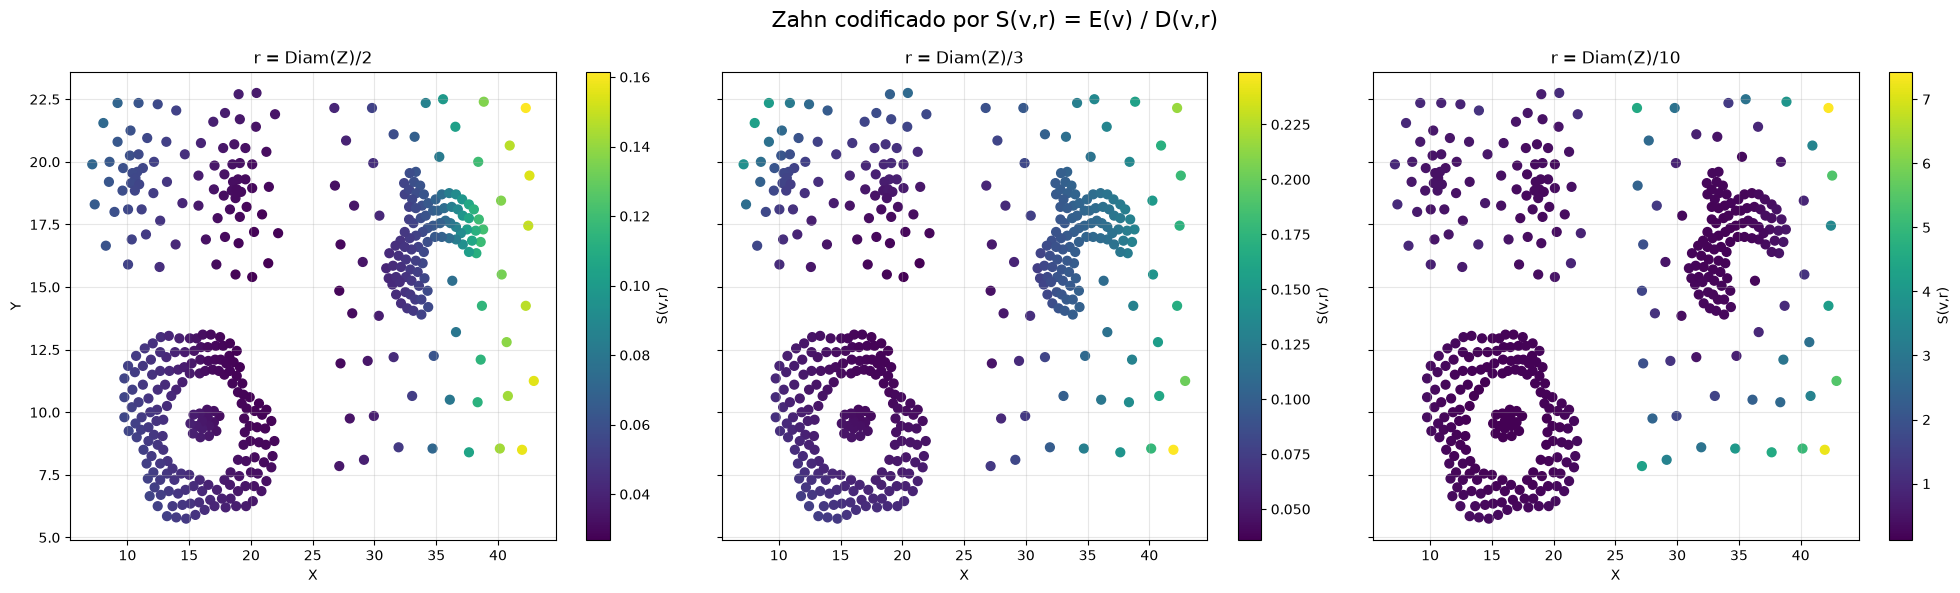

In [28]:
columnas_S = [
    ("S_Diam/2", "r = Diam(Z)/2"),
    ("S_Diam/3", "r = Diam(Z)/3"),
    ("S_Diam/10", "r = Diam(Z)/10")
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6),
    sharex=True,
    sharey=True
)

for ax, (columna, titulo) in zip(axes, columnas_S):

    scatter = ax.scatter(
        df["X"],
        df["Y"],
        c=df[columna],
        cmap="viridis",
        s=40
    )

    ax.set_title(titulo)
    ax.set_xlabel("X")
    ax.grid(alpha=0.3)

    plt.colorbar(
        scatter,
        ax=ax,
        label="S(v,r)"
    )

axes[0].set_ylabel("Y")

fig.suptitle(
    "Zahn codificado por S(v,r) = E(v) / D(v,r)",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [29]:
# Guarda resultado_distance_based.csv con los resultados de anomalías para p=0.10 y r=18
p = 0.10
r = 18

anomalias_distance = resultados_db[(p, r)]

resultado_distance = pd.DataFrame({
    "indice": df.index,
    "anomalia_distance": anomalias_distance
})

resultado_distance.to_csv(
    "resultado_distance_based.csv",
    index=False
)

resultado_distance.head()

,indice,anomalia_distance
0,0,True
1,1,True
2,2,True
3,3,True
4,4,True
